# Notebook 01: Data Preparation and Exploratory Data Analysis

## Purpose

This notebook loads the Kaggle IAB website categorization dataset, explores its structure and quality, performs cleaning, and produces train/val/test splits ready for downstream notebooks. By the end, we will have a clear picture of what the data looks like -- how many domains, how many categories, what text is available, and what challenges we face for multi-label classification.

## What This Notebook Produces

| Artifact | Path | Description |
|---|---|---|
| Training set | `data/processed/train.parquet` | 80% of data |
| Validation set | `data/processed/val.parquet` | 10% of data |
| Test set | `data/processed/test.parquet` | 10% of data |
| Label mapping | `data/processed/label_info.parquet` | Category hierarchy + statistics |

## Data Source

**Kaggle**: [bpmtips/websiteiabcategorization](https://www.kaggle.com/datasets/bpmtips/websiteiabcategorization)

The dataset contains real website domains with their IAB content taxonomy categories, page titles, and meta descriptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True)

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Files available: {[f.name for f in DATA_DIR.iterdir() if f.is_file()]}")

Data directory: /Users/nipun.batra/Downloads/ML/IAB_LLM_Distillation_Classification/data
Files available: ['training_data_en.csv', 'training_data.csv', 'websiteiabcategorization.zip']


## 1. Load Raw Data

### Reasoning: Why Use the English-Only File?

The Kaggle zip contains three files:
- `training_data.csv` (123K rows) -- all languages
- `training_data_en.csv` (36K rows) -- English-only subset
- `70-million-domains-with-meta-2022-12.csv` (25GB) -- massive unlabeled corpus

We start with **`training_data.csv`** (the full labeled dataset) because:
- More training data is generally better for a 700-class problem
- Our embedding models (E5, MiniLM) are multilingual-capable
- We can always filter to English later if needed
- 123K domains gives us a solid base for distillation

The files have **no header row** based on inspection. The columns appear to be:
1. Traffic rank (numeric, sometimes `\N` for null)
2. Domain ID (numeric)
3. Domain name (URL)
4. IAB category path (hierarchical, `/`-separated)
5. Page title
6. Meta description
7. Keywords (often empty)

In [2]:
column_names = ['traffic_rank', 'domain_id', 'domain', 'category_path', 'title', 'description', 'keywords']

df_full = pd.read_csv(
    DATA_DIR / 'training_data.csv',
    header=None,
    names=column_names,
    dtype={'traffic_rank': str, 'domain_id': str},
    na_values=[r'\N', ''],
    quotechar='"',
    on_bad_lines='skip'
)

df_en = pd.read_csv(
    DATA_DIR / 'training_data_en.csv',
    header=None,
    names=column_names,
    dtype={'traffic_rank': str, 'domain_id': str},
    na_values=[r'\N', ''],
    quotechar='"',
    on_bad_lines='skip'
)

print(f"Full dataset: {len(df_full):,} rows")
print(f"English-only: {len(df_en):,} rows")
print(f"\nFull dataset columns and dtypes:")
print(df_full.dtypes)
print(f"\nFirst 5 rows:")
df_full.head()

Full dataset: 98,951 rows
English-only: 36,119 rows

Full dataset columns and dtypes:
traffic_rank     str
domain_id        str
domain           str
category_path    str
title            str
description      str
keywords         str
dtype: object

First 5 rows:


,traffic_rank,domain_id,domain,category_path,title,description,keywords
0,194,1871997,www.allesiszoleuk.nl,/Shopping,welkom | allesiszoleuk,eerst even een berichtje aan mijn lieve winkel...,NaN
1,0,5268113,www.tricom.se,/Computers & Electronics/Computer Hardware,tricom,NaN,NaN
2,257,1500690,jpgbxt.web.app,/Internet & Telecom,ダウンロードしたnetflixを変換する - jpgbxt.web.app,ユーザーのアイデアを集めた世界最大のコレクション、pinterest で yukilee（y...,NaN
3,0,3213540,www.farmaciarodriguezprada.es,/Beauty & Fitness/Face & Body Care,farmacia rodriguez prada abiertos todo el día....,"comprar en línea, nuevos papas, kit mama, pac...",comprar en linea minavit gripping gel pack be...
4,487,690628,www.g-music.com.tw,/Arts & Entertainment/Music & Audio,玫瑰大眾購物網,玫瑰大眾娛樂股份有限公司成立以來，堅持以傳播好音樂為宗旨，結合實體唱片通路、唱片公司、網站，...,NaN


### Reasoning: Initial Data Quality Assessment

Before any analysis, we need to understand the completeness of each column. For our classification task, the critical columns are:
- `domain` -- the primary input (must be present for every row)
- `category_path` -- the label (must be present)
- `title` and `description` -- auxiliary text that enriches the domain signal

Missing values in `title`/`description` are acceptable (we can still classify from domain name alone), but missing `domain` or `category_path` means the row is useless.

In [3]:
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing = df_full.isnull().sum()
missing_pct = (missing / len(df_full) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Present Count': len(df_full) - missing,
    'Present %': (100 - missing_pct).round(1)
})
print(missing_df)

print(f"\n--- Critical Check ---")
print(f"Rows missing domain: {df_full['domain'].isnull().sum()}")
print(f"Rows missing category_path: {df_full['category_path'].isnull().sum()}")
print(f"Rows with BOTH domain and category present: {df_full[['domain', 'category_path']].notna().all(axis=1).sum():,}")

MISSING VALUES ANALYSIS
               Missing Count  Missing %  Present Count  Present %
traffic_rank           20235       20.4          78716       79.6
domain_id                243        0.2          98708       99.8
domain                   261        0.3          98690       99.7
category_path            266        0.3          98685       99.7
title                   3147        3.2          95804       96.8
description            27884       28.2          71067       71.8
keywords               68307       69.0          30644       31.0

--- Critical Check ---
Rows missing domain: 261
Rows missing category_path: 266
Rows with BOTH domain and category present: 98,685


In [4]:
print("\n=" * 60)
print("SAMPLE VALUES FOR EACH COLUMN")
print("=" * 60)

for col in column_names:
    non_null = df_full[col].dropna()
    print(f"\n--- {col} (non-null: {len(non_null):,}) ---")
    if len(non_null) > 0:
        samples = non_null.sample(min(5, len(non_null)), random_state=42)
        for val in samples:
            print(f"  {str(val)[:100]}")


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
SAMPLE VALUES FOR EACH COLUMN

--- traffic_rank (non-null: 78,716) ---
  417
  140
  4820
  0
  978

--- domain_id (non-null: 98,708) ---
  7367845
  547728
  1652396
  389105
  1898563

--- domain (non-null: 98,690) ---
  eastoncourier.news
  weblite.me
  civiljungle.com
  www.marktplaats.nl
  www.vipbottles.co.uk

--- category_path (non-null: 98,685) ---
  /Online Communities/Blogging Resources & Services
  /Shopping/Apparel
  /Online Communities
  /Business & Industrial/Textiles & Nonwovens
  /People & Society/Social Issues & Advocacy/Charity & Philanthropy

--- title (non-null: 95,804) ---
  negozio ecobag - sacchi, borse e imballaggi per negozi e commercianti a dei prezzi molto bassi
  crossfit midtown – crossfit midtown
  بيع وشراء الخدمات باسعار معقولة -  اي خدمة
  kartal escort, escort kartal, kartal bayan escort
  comunidad todito cash

--- description (non-

In [5]:
print("CLEANING PIPELINE")
print("=" * 60)

df = df_full.copy()
print(f"Starting rows: {len(df):,}")

# Step 1: Drop rows missing critical columns
df = df.dropna(subset=['domain', 'category_path'])
print(f"After dropping missing domain/category: {len(df):,}")

# Step 1b: Remove rows where category_path is malformed (doesn't start with /)
valid_cat_mask = df['category_path'].str.startswith('/')
invalid_count = (~valid_cat_mask).sum()
df = df[valid_cat_mask]
print(f"After removing malformed category paths: {len(df):,} (removed {invalid_count} garbage rows)")

# Step 2: Strip whitespace
for col in ['domain', 'category_path', 'title', 'description', 'keywords']:
    df[col] = df[col].str.strip()

# Step 3: Normalize domain names
df['domain_clean'] = df['domain'].str.lower().str.replace('^www\\.', '', regex=True)

# Step 4: Parse category hierarchy
df['category_path_clean'] = df['category_path'].str.strip('/')
df['tier1_raw'] = df['category_path_clean'].str.split('/').str[0]

# Step 4b: Consolidate variant Tier-1 category names
# The dataset contains two naming conventions for the same categories:
# - Canonical form: "Computers & Electronics" (uses &)
# - Variant form: "Computers Electronics and Technology" (uses "and", different wording)
# We map all variants to the canonical form.
TIER1_CONSOLIDATION = {
    'Computers Electronics and Technology': 'Computers & Electronics',
    'Science and Education': 'Jobs & Education',
    'Business and Consumer Services': 'Business & Industrial',
    'eCommerce & Shopping': 'Shopping',
    'Lifestyle': 'Hobbies & Leisure',
    'Travel and Tourism': 'Travel',
    'Hobbies and Leisure': 'Hobbies & Leisure',
    'Reference Materials': 'Reference',
    'Gambling': 'Games',
    'Law and Government': 'Law & Government',
    'Heavy Industry and Engineering': 'Business & Industrial',
    'Food and Drink': 'Food & Drink',
    'Community and Society': 'People & Society',
    'Pets and Animals': 'Pets & Animals',
    'Vehicles': 'Autos & Vehicles',
    'Jobs and Career': 'Jobs & Education',
    'Home and Garden': 'Home & Garden',
}

df['tier1'] = df['tier1_raw'].replace(TIER1_CONSOLIDATION)
consolidated_count = (df['tier1'] != df['tier1_raw']).sum()
print(f"After consolidating variant Tier-1 names: {consolidated_count:,} rows remapped")
print(f"  Tier-1 categories: {df['tier1_raw'].nunique()} raw --> {df['tier1'].nunique()} canonical")

df['tier2'] = df['category_path_clean'].str.split('/').apply(
    lambda parts: '/'.join(parts[:2]) if len(parts) >= 2 else parts[0]
)

# Step 5: Remove exact duplicates (same domain + same category)
before_dedup = len(df)
df = df.drop_duplicates(subset=['domain_clean', 'category_path_clean'])
print(f"After deduplication: {len(df):,} (removed {before_dedup - len(df):,} exact duplicates)")

# Remove rows where category is empty after cleaning
df = df[df['tier1'].str.len() > 0]
print(f"After removing empty categories: {len(df):,}")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Unique domains: {df['domain_clean'].nunique():,}")
print(f"Unique Tier-1 categories: {df['tier1'].nunique()}")
print(f"Unique Tier-2 categories: {df['tier2'].nunique()}")
print(f"Unique full category paths: {df['category_path_clean'].nunique()}")

CLEANING PIPELINE
Starting rows: 98,951
After dropping missing domain/category: 98,685
After removing malformed category paths: 98,680 (removed 5 garbage rows)
After consolidating variant Tier-1 names: 803 rows remapped
  Tier-1 categories: 44 raw --> 27 canonical
After deduplication: 97,961 (removed 719 exact duplicates)
After removing empty categories: 97,961

Final dataset shape: (97961, 12)
Unique domains: 96,986


Unique Tier-1 categories: 27
Unique Tier-2 categories: 398


Unique full category paths: 668


### Reasoning: Why Consolidate Tier-1 Category Variants?

The raw dataset contains **44 unique Tier-1 strings**, but many are variant spellings of the same semantic category. For example:

| Variant in Dataset | Canonical Form | Difference |
|---|---|---|
| Computers Electronics and Technology | Computers & Electronics | "and" vs "&", extra words |
| Science and Education | Jobs & Education | Different naming convention |
| eCommerce & Shopping | Shopping | Prefix variant |
| Hobbies and Leisure | Hobbies & Leisure | "and" vs "&" |
| Vehicles | Autos & Vehicles | Abbreviated form |

These variants likely come from different data sources or annotation batches within the Kaggle dataset. Without consolidation, the 17 variant categories (totaling ~800 rows) would create tiny groups that break stratified splitting and fragment the label space.

**Decision**: We map all 17 variants to their closest canonical category, reducing from 44 to 27 Tier-1 categories. This means:
- Stratified splitting works reliably (minimum group size jumps from 22 to 262)
- The label space is cleaner for downstream Claude labeling
- We preserve the original `tier1_raw` column in case we need to audit the mapping later

**Alternative rejected**: Simply grouping rare categories into `_RARE_` for stratification. This would preserve the fragmented labels downstream, making the classification task harder with no benefit -- these variants truly represent the same semantic category.

## 3. Category Distribution Analysis

### Reasoning: Why Category Distribution Matters

For multi-label classification with hundreds of classes, the distribution of labels determines:
- **Class imbalance strategy** -- if some categories have 10,000 examples and others have 10, we need techniques like asymmetric loss or oversampling
- **Evaluation metric choice** -- macro-F1 (treats all classes equally) vs. micro-F1 (weighted by frequency) tells different stories
- **Whether hierarchical classification is viable** -- requires enough examples in each Tier-1 to train sub-classifiers
- **Student model capacity** -- rare classes may need the teacher (Claude) labels more than common ones

We expect a power-law distribution (few categories with many domains, many categories with few domains) because web content naturally clusters in popular topics.

In [6]:
print("TIER-1 CATEGORY DISTRIBUTION")
print("=" * 60)

tier1_counts = df['tier1'].value_counts()
tier1_pct = (tier1_counts / len(df) * 100).round(1)

tier1_summary = pd.DataFrame({
    'Count': tier1_counts,
    'Percentage': tier1_pct,
    'Cumulative %': tier1_pct.cumsum().round(1)
})
print(tier1_summary.to_string())

print(f"\n--- Summary Statistics ---")
print(f"Total Tier-1 categories: {len(tier1_counts)}")
print(f"Largest category: {tier1_counts.index[0]} ({tier1_counts.iloc[0]:,} domains, {tier1_pct.iloc[0]}%)")
print(f"Smallest category: {tier1_counts.index[-1]} ({tier1_counts.iloc[-1]:,} domains, {tier1_pct.iloc[-1]}%)")
print(f"Imbalance ratio (largest/smallest): {tier1_counts.iloc[0] / tier1_counts.iloc[-1]:.1f}x")
print(f"Median category size: {tier1_counts.median():.0f}")
print(f"Categories with >5000 domains: {(tier1_counts > 5000).sum()}")
print(f"Categories with <1000 domains: {(tier1_counts < 1000).sum()}")

TIER-1 CATEGORY DISTRIBUTION
                         Count  Percentage  Cumulative %
tier1                                                   
Business & Industrial    10523        10.7          10.7
Arts & Entertainment      9773        10.0          20.7
Shopping                  8051         8.2          28.9
Home & Garden             6086         6.2          35.1
Internet & Telecom        5536         5.7          40.8
Computers & Electronics   5501         5.6          46.4
Hobbies & Leisure         5323         5.4          51.8
Online Communities        5076         5.2          57.0
People & Society          4327         4.4          61.4
Health                    3577         3.7          65.1
Autos & Vehicles          3349         3.4          68.5
Jobs & Education          3236         3.3          71.8
Beauty & Fitness          3224         3.3          75.1
Sports                    3181         3.2          78.3
Food & Drink              3154         3.2          81.5
Ne

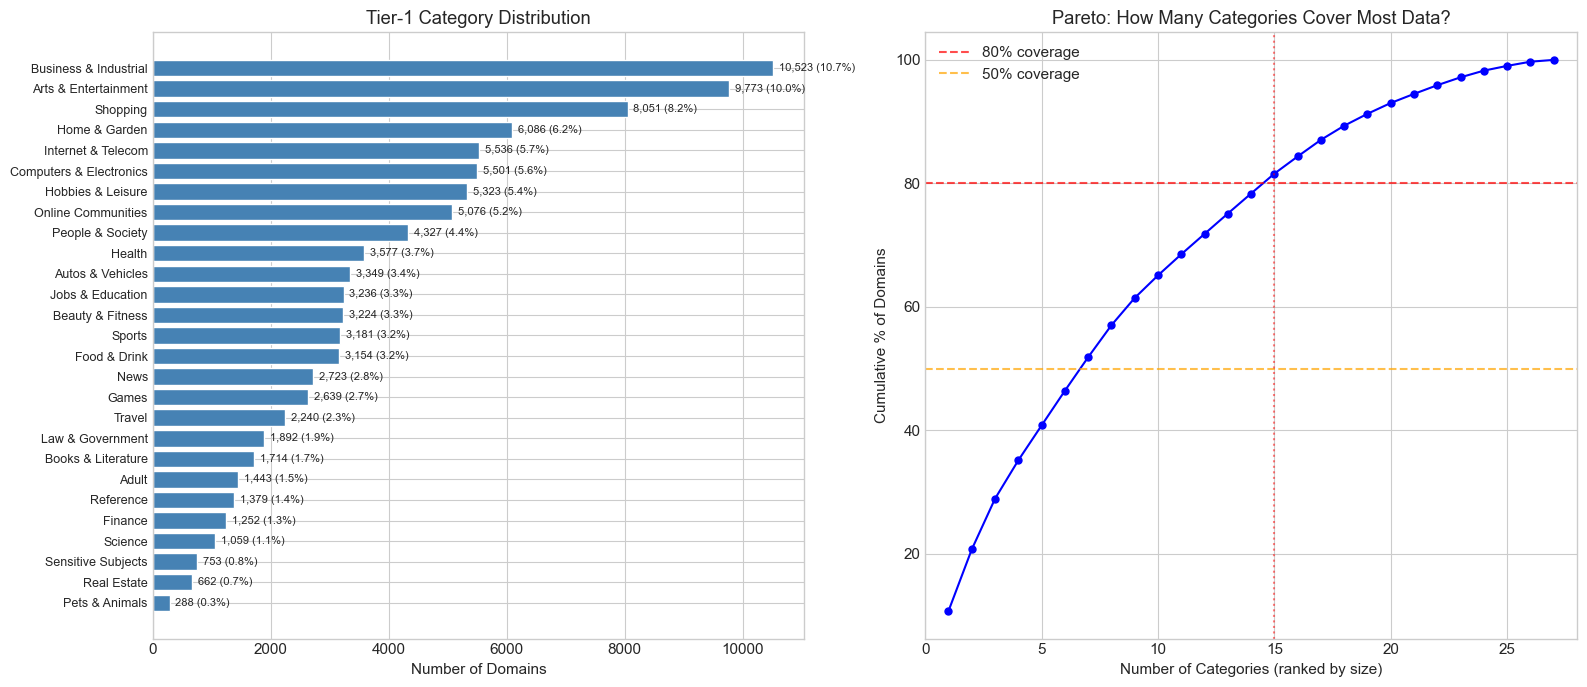


Pareto insight: Top 15 categories (out of 27) cover 80% of all domains.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Tier-1 bar chart
ax = axes[0]
bars = ax.barh(range(len(tier1_counts)), tier1_counts.values, color='steelblue', edgecolor='white')
ax.set_yticks(range(len(tier1_counts)))
ax.set_yticklabels(tier1_counts.index, fontsize=9)
ax.set_xlabel('Number of Domains')
ax.set_title('Tier-1 Category Distribution')
ax.invert_yaxis()

for i, (count, pct) in enumerate(zip(tier1_counts.values, tier1_pct.values)):
    ax.text(count + 100, i, f'{count:,} ({pct}%)', va='center', fontsize=8)

# Plot 2: Cumulative distribution (Pareto)
ax = axes[1]
cumulative = tier1_counts.cumsum() / tier1_counts.sum() * 100
ax.plot(range(1, len(cumulative)+1), cumulative.values, 'b-o', markersize=5)
ax.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% coverage')
ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50% coverage')
n_for_80 = (cumulative >= 80).idxmax()
ax.axvline(x=list(cumulative.index).index(n_for_80)+1, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Number of Categories (ranked by size)')
ax.set_ylabel('Cumulative % of Domains')
ax.set_title('Pareto: How Many Categories Cover Most Data?')
ax.legend()
ax.set_xlim(0, len(cumulative)+1)

plt.tight_layout()
plt.savefig('../plots/01_tier1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

n_for_80_idx = list(cumulative.values >= 80).index(True) + 1
print(f"\nPareto insight: Top {n_for_80_idx} categories (out of {len(tier1_counts)}) cover 80% of all domains.")

In [8]:
print("TIER-2 CATEGORY DISTRIBUTION (top 30 and tail)")
print("=" * 60)

tier2_counts = df['tier2'].value_counts()

print(f"Total unique Tier-2 categories: {len(tier2_counts)}")
print(f"\nTop 20 Tier-2 categories:")
print(tier2_counts.head(20).to_string())

print(f"\n--- Tier-2 Distribution Statistics ---")
print(f"Median examples per Tier-2 category: {tier2_counts.median():.0f}")
print(f"Mean examples per Tier-2 category: {tier2_counts.mean():.0f}")
print(f"Categories with <10 examples: {(tier2_counts < 10).sum()} ({(tier2_counts < 10).sum()/len(tier2_counts)*100:.1f}%)")
print(f"Categories with <50 examples: {(tier2_counts < 50).sum()} ({(tier2_counts < 50).sum()/len(tier2_counts)*100:.1f}%)")
print(f"Categories with >1000 examples: {(tier2_counts > 1000).sum()}")

print(f"\nBottom 10 Tier-2 categories (rarest):")
print(tier2_counts.tail(10).to_string())

TIER-2 CATEGORY DISTRIBUTION (top 30 and tail)
Total unique Tier-2 categories: 398

Top 20 Tier-2 categories:
tier2
Online Communities                              4409
Shopping/Apparel                                4077
Business & Industrial                           3812
Arts & Entertainment                            2920
Internet & Telecom/Web Services                 2764
Jobs & Education/Education                      2592
Arts & Entertainment/Music & Audio              2319
Business & Industrial/Business Services         2063
News                                            2058
People & Society/Religion & Belief              2054
Internet & Telecom                              1936
Beauty & Fitness/Face & Body Care               1814
Hobbies & Leisure                               1721
Shopping                                        1525
Autos & Vehicles/Vehicle Parts & Services       1507
Adult                                           1443
Books & Literature                  

## 5. Text Quality Analysis

### Reasoning: What Text Do We Have to Work With?

The quality and availability of text signals determines our strategy:

- **If most domains have rich titles + descriptions**: The embedding models will have plenty of signal. We can concatenate domain + title + description as input text.
- **If most domains have ONLY the domain name**: The embedding models must infer category from just the URL string (e.g., "espn.com" --> Sports). This is harder but still feasible because these models have seen these domains in their pre-training data.
- **Text length distribution**: Determines whether we need long-context models (8K tokens) or short-context (512 tokens) is fine.

We also check for garbage text (HTML artifacts, placeholder text, error pages like "403 Forbidden") that should be excluded.

In [9]:
print("TEXT QUALITY ANALYSIS")
print("=" * 60)

# Text availability
has_title = df['title'].notna() & (df['title'].str.len() > 2)
has_desc = df['description'].notna() & (df['description'].str.len() > 2)
has_keywords = df['keywords'].notna() & (df['keywords'].str.len() > 2)

print(f"Domains with meaningful title (>2 chars): {has_title.sum():,} ({has_title.mean()*100:.1f}%)")
print(f"Domains with meaningful description (>2 chars): {has_desc.sum():,} ({has_desc.mean()*100:.1f}%)")
print(f"Domains with keywords: {has_keywords.sum():,} ({has_keywords.mean()*100:.1f}%)")
print(f"Domains with title AND description: {(has_title & has_desc).sum():,} ({(has_title & has_desc).mean()*100:.1f}%)")
print(f"Domains with ONLY domain name (no title, no desc): {(~has_title & ~has_desc).sum():,} ({(~has_title & ~has_desc).mean()*100:.1f}%)")

# Text length analysis
print(f"\n--- Text Length Statistics ---")
df['domain_len'] = df['domain_clean'].str.len()
df['title_len'] = df['title'].fillna('').str.len()
df['desc_len'] = df['description'].fillna('').str.len()

for col, name in [('domain_len', 'Domain name'), ('title_len', 'Title'), ('desc_len', 'Description')]:
    valid = df[col][df[col] > 0]
    if len(valid) > 0:
        print(f"  {name}: median={valid.median():.0f} chars, mean={valid.mean():.0f}, p95={valid.quantile(0.95):.0f}, max={valid.max():.0f}")

TEXT QUALITY ANALYSIS
Domains with meaningful title (>2 chars): 95,156 (97.1%)
Domains with meaningful description (>2 chars): 70,557 (72.0%)
Domains with keywords: 30,221 (30.9%)
Domains with title AND description: 70,426 (71.9%)
Domains with ONLY domain name (no title, no desc): 2,674 (2.7%)

--- Text Length Statistics ---
  Domain name: median=16 chars, mean=16, p95=27, max=61
  Title: median=46 chars, mean=50, p95=109, max=1017
  Description: median=136 chars, mean=144, p95=288, max=35942


In [10]:
# Construct the combined text field that will be used for embedding
def build_domain_text(row):
    """Combine available text fields into a single string for embedding."""
    parts = [row['domain_clean']]
    if pd.notna(row['title']) and len(str(row['title']).strip()) > 2:
        parts.append(str(row['title']).strip())
    if pd.notna(row['description']) and len(str(row['description']).strip()) > 2:
        parts.append(str(row['description']).strip())
    return ' | '.join(parts)

df['text'] = df.apply(build_domain_text, axis=1)
df['text_len'] = df['text'].str.len()

print("COMBINED TEXT FIELD (domain | title | description)")
print("=" * 60)
print(f"Text length: median={df['text_len'].median():.0f}, mean={df['text_len'].mean():.0f}, p95={df['text_len'].quantile(0.95):.0f}")
print(f"\nSample combined texts:")
for _, row in df.sample(8, random_state=42).iterrows():
    print(f"  [{row['tier1'][:20]:20s}] {row['text'][:120]}")

COMBINED TEXT FIELD (domain | title | description)
Text length: median=162, mean=174, p95=360

Sample combined texts:
  [Online Communities  ] creativewonderland-dc.blogspot.com | willkommen im creativewonderland
  [Health              ] ljekarna-rijeka.hr | ljekarna rijeka, online ljekarna | online ljekarna rijeka nudi široku ponudu dodataka prehrani, der
  [Sports              ] sportslens.com | football news & transfer rumours | sportslens.com | sportslens.com brings you the latest football news,
  [Law & Government    ] dekapolice.gr | δημοκρατική ενωτική κίνηση αστυνομικών (δ.ε.κ.α.) | συνδικαλιστική παράταξη αστυνομίας,ενημέρωση,άρθρα,ε
  [Hobbies & Leisure   ] vohotky.com | vohotky - интернет магазин рукоделие, хенд мейд, | самый большой выбор товаров для рукоделия на любой вкус
  [Arts & Entertainment] gshow.globo.com | gshow - de fã pra fã, a gente vibra na mesma sintonia | a gente conecta os apaixonados por entretenime
  [Home & Garden       ] bartsch-elektro.de | bartsch ele

### Reasoning: Text Length Implications for Model Choice

The text length distribution tells us whether we need long-context models:

| Model | Max Tokens | Approx Max Chars | Sufficient? |
|---|---|---|---|
| MiniLM / E5-small / E5-base | 512 tokens | ~2000 chars | Check p95 below |
| ModernBERT | 8192 tokens | ~32000 chars | Always sufficient |

If our p95 text length is under 500 characters (~128 tokens), then ALL models can handle our inputs without truncation. This means the smaller/faster models are not disadvantaged, and **e5-small (512 token context) is a valid production choice**.

For domain names specifically (median ~15-20 chars), even the smallest models have absurd headroom. The text enrichment (title + description) adds length but typically stays well under 512 tokens.

In [11]:
# Check for garbage/placeholder text
print("GARBAGE TEXT DETECTION")
print("=" * 60)

garbage_patterns = [
    'forbidden', '403', '404', 'not found', 'error',
    'access denied', 'under construction', 'coming soon',
    'domain for sale', 'parked', 'expired'
]

garbage_mask = df['title'].fillna('').str.lower().str.contains('|'.join(garbage_patterns), regex=True)
print(f"Domains with potential garbage titles: {garbage_mask.sum():,} ({garbage_mask.mean()*100:.1f}%)")

if garbage_mask.sum() > 0:
    print(f"\nExamples of garbage titles:")
    for _, row in df[garbage_mask].sample(min(10, garbage_mask.sum()), random_state=42).iterrows():
        print(f"  {row['domain_clean']}: '{row['title']}'")

print(f"\nDecision: We will KEEP these rows. The domain name itself still carries")
print(f"classification signal (e.g., 'soccerplayer.net' is clearly Sports even with")
print(f"a garbage title). The embedding model uses all text but weighs domain name heavily.")

GARBAGE TEXT DETECTION
Domains with potential garbage titles: 214 (0.2%)

Examples of garbage titles:
\'
  tripadvisor.com.br: 'access denied'
  worldmarts.in: '404 not found'
  coinmarketcap.com: 'error: the request could not be satisfied'
  fema.gov: 'access denied'
  petfinder.com: '403 forbidden'
  heyfilesrlmn.netlify.app: 'filmes de terror completos e dublados online - heyfilesrlmn.netlify.app'
  lavoixdunord.fr: 'access denied'
  lamborghini.tractorerrorcode.com: 'lamborghini tractor error codes | tractorerrorcode.com'
  tripadvisor.it: 'access denied'

Decision: We will KEEP these rows. The domain name itself still carries
classification signal (e.g., 'soccerplayer.net' is clearly Sports even with
a garbage title). The embedding model uses all text but weighs domain name heavily.


## 6. Train / Validation / Test Split

### Reasoning: Splitting Strategy for Multi-Label Data

The split must satisfy two requirements:

1. **No data leakage**: The same domain must NOT appear in both train and test. If "espn.com" appears in train with label "Sports" and in test with label "Football", the model memorizes the domain rather than learning to classify.

2. **Stratification on Tier-1**: We want each split to have approximately the same Tier-1 category distribution. This prevents the situation where a rare category (e.g., "Pets") has all its examples in train and none in test, making evaluation impossible for that category.

**Split approach**: We split at the DOMAIN level (not row level), then collect all rows for each domain into the assigned split. For stratification, we use each domain's PRIMARY (most common) Tier-1 category as the stratification key.

**Split ratio**: 80/10/10 (train/val/test)
- Train (80%): Used for student model training and TF-IDF baseline
- Validation (10%): Hyperparameter tuning, threshold optimization, early stopping
- Test (10%): Final held-out evaluation, never touched during development

### Worked Example: Why Split at Domain Level

```
Suppose espn.com has 2 rows:
  Row A: espn.com --> Sports/Football
  Row B: espn.com --> Arts & Entertainment

BAD split (row-level): Row A in train, Row B in test
  - Model sees espn.com in training, memorizes it
  - Test evaluation is artificially inflated

GOOD split (domain-level): Both rows go to train OR both to test
  - Model never sees test domains during training
  - Evaluation reflects true generalization ability
```

In [12]:
from sklearn.model_selection import train_test_split

print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)

# Get unique domains with their primary (most frequent) Tier-1 category
domain_primary_cat = df.groupby('domain_clean')['tier1'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
domain_primary_cat.columns = ['domain_clean', 'primary_tier1']

print(f"Unique domains to split: {len(domain_primary_cat):,}")
print(f"Tier-1 categories for stratification: {domain_primary_cat['primary_tier1'].nunique()}")

# Check minimum group size -- after consolidation all groups should be large enough
tier1_domain_counts = domain_primary_cat['primary_tier1'].value_counts()
print(f"Smallest category group: {tier1_domain_counts.min()} domains ({tier1_domain_counts.idxmin()})")
print(f"Largest category group: {tier1_domain_counts.max()} domains ({tier1_domain_counts.idxmax()})")

# First split: 80% train, 20% temp (will become val + test)
train_domains, temp_domains = train_test_split(
    domain_primary_cat,
    test_size=0.2,
    random_state=42,
    stratify=domain_primary_cat['primary_tier1']
)

# Second split: 50/50 of temp --> 10% val, 10% test
val_domains, test_domains = train_test_split(
    temp_domains,
    test_size=0.5,
    random_state=42,
    stratify=temp_domains['primary_tier1']
)

print(f"\nTrain domains: {len(train_domains):,}")
print(f"Val domains:   {len(val_domains):,}")
print(f"Test domains:  {len(test_domains):,}")

# Assign rows to splits based on domain membership
train_df = df[df['domain_clean'].isin(train_domains['domain_clean'])].copy()
val_df = df[df['domain_clean'].isin(val_domains['domain_clean'])].copy()
test_df = df[df['domain_clean'].isin(test_domains['domain_clean'])].copy()

print(f"\nTrain rows: {len(train_df):,}")
print(f"Val rows:   {len(val_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Total:      {len(train_df) + len(val_df) + len(test_df):,} (original: {len(df):,})")

# Verify no domain leakage
train_set = set(train_df['domain_clean'])
val_set = set(val_df['domain_clean'])
test_set = set(test_df['domain_clean'])
assert len(train_set & val_set) == 0, "LEAKAGE: train/val overlap!"
assert len(train_set & test_set) == 0, "LEAKAGE: train/test overlap!"
assert len(val_set & test_set) == 0, "LEAKAGE: val/test overlap!"
print(f"\nLeakage check PASSED: no domain appears in multiple splits.")

TRAIN / VALIDATION / TEST SPLIT


Unique domains to split: 96,986
Tier-1 categories for stratification: 27
Smallest category group: 264 domains (Pets & Animals)
Largest category group: 10460 domains (Business & Industrial)

Train domains: 77,588
Val domains:   9,699
Test domains:  9,699



Train rows: 78,357
Val rows:   9,810
Test rows:  9,794
Total:      97,961 (original: 97,961)

Leakage check PASSED: no domain appears in multiple splits.


In [13]:
# Verify stratification quality
print("STRATIFICATION VERIFICATION")
print("=" * 60)

train_dist = train_df['tier1'].value_counts(normalize=True) * 100
val_dist = val_df['tier1'].value_counts(normalize=True) * 100
test_dist = test_df['tier1'].value_counts(normalize=True) * 100

strat_check = pd.DataFrame({
    'Train %': train_dist,
    'Val %': val_dist,
    'Test %': test_dist,
    'Max Deviation': abs(train_dist - test_dist)
}).round(1).sort_values('Train %', ascending=False)

print(strat_check.head(15).to_string())
print(f"\nMax deviation between train and test: {strat_check['Max Deviation'].max():.1f} percentage points")
print(f"Mean deviation: {strat_check['Max Deviation'].mean():.2f} percentage points")

if strat_check['Max Deviation'].max() < 2.0:
    print(f"\nStratification is GOOD: all splits have nearly identical category distributions.")
else:
    print(f"\nWARNING: some categories have significant distribution shift between splits.")

STRATIFICATION VERIFICATION
                         Train %  Val %  Test %  Max Deviation
tier1                                                         
Business & Industrial       10.7   10.8    10.8            0.0
Arts & Entertainment        10.0   10.0    10.0            0.0
Shopping                     8.2    8.2     8.2            0.0
Home & Garden                6.2    6.2     6.2            0.0
Internet & Telecom           5.7    5.6     5.7            0.0
Computers & Electronics      5.6    5.6     5.6            0.0
Hobbies & Leisure            5.4    5.4     5.4            0.0
Online Communities           5.2    5.2     5.2            0.0
People & Society             4.4    4.4     4.4            0.0
Health                       3.6    3.7     3.7            0.0
Autos & Vehicles             3.4    3.4     3.4            0.0
Jobs & Education             3.3    3.3     3.3            0.0
Beauty & Fitness             3.3    3.3     3.3            0.0
Food & Drink               

## 7. Save Processed Data

### Reasoning: Output Format Choice

We save as **Parquet** (not CSV) because:
- **3-5x smaller file size** (columnar compression)
- **Preserves dtypes** (no re-parsing on load)
- **Faster I/O** (columnar reads only the columns you need)
- **Industry standard** for ML pipelines

Each row in the output represents one (domain, category) pair. Downstream notebooks that need the multi-label view will group by domain.

In [14]:
# Select columns to save
output_cols = ['domain_clean', 'domain', 'category_path_clean', 'tier1', 'tier2', 'title', 'description', 'keywords', 'text']

train_df[output_cols].to_parquet(PROCESSED_DIR / 'train.parquet', index=False)
val_df[output_cols].to_parquet(PROCESSED_DIR / 'val.parquet', index=False)
test_df[output_cols].to_parquet(PROCESSED_DIR / 'test.parquet', index=False)

print("SAVED ARTIFACTS")
print("=" * 60)
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    path = PROCESSED_DIR / f'{split_name}.parquet'
    size_mb = path.stat().st_size / 1024 / 1024
    print(f"  {path.name}: {len(split_df):,} rows, {split_df['domain_clean'].nunique():,} domains, {size_mb:.1f} MB")

SAVED ARTIFACTS
  train.parquet: 78,357 rows, 77,588 domains, 27.4 MB
  val.parquet: 9,810 rows, 9,699 domains, 3.3 MB
  test.parquet: 9,794 rows, 9,699 domains, 3.5 MB


In [15]:
# Save label information for downstream notebooks
label_info = pd.DataFrame({
    'category_path': df['category_path_clean'].unique()
})
label_info['tier1_raw'] = label_info['category_path'].str.split('/').str[0]
label_info['tier1'] = label_info['tier1_raw'].replace(TIER1_CONSOLIDATION)
label_info['tier2'] = label_info['category_path'].str.split('/').apply(
    lambda parts: '/'.join(parts[:2]) if len(parts) >= 2 else parts[0]
)
label_info['depth'] = label_info['category_path'].str.count('/') + 1
label_info['train_count'] = label_info['category_path'].map(
    train_df['category_path_clean'].value_counts()
).fillna(0).astype(int)

label_info = label_info.sort_values('train_count', ascending=False).reset_index(drop=True)
label_info.to_parquet(PROCESSED_DIR / 'label_info.parquet', index=False)

print(f"\nLabel info saved: {len(label_info)} unique category paths")
print(f"  Tier-1 categories (canonical): {label_info['tier1'].nunique()}")
print(f"  Tier-2 categories: {label_info['tier2'].nunique()}")
print(f"  Max depth: {label_info['depth'].max()} levels")
print(f"\nLabel hierarchy (first 20):")
print(label_info[['category_path', 'tier1', 'depth', 'train_count']].head(20).to_string())


Label info saved: 668 unique category paths
  Tier-1 categories (canonical): 27
  Tier-2 categories: 398
  Max depth: 3 levels

Label hierarchy (first 20):
                                                            category_path                    tier1  depth  train_count
0                                                      Online Communities       Online Communities      1         3517
1                                                   Business & Industrial    Business & Industrial      1         3059
2                                                    Arts & Entertainment     Arts & Entertainment      1         2315
3                Internet & Telecom/Web Services/Web Design & Development       Internet & Telecom      3         1691
4                                      People & Society/Religion & Belief         People & Society      2         1649
5                                                                    News                     News      1         1635
6         

## 8. Summary and Key Findings

### Reasoning: What We Learned and How It Shapes Downstream Decisions

In [16]:
print("=" * 70)
print("NOTEBOOK 01 SUMMARY: KEY FINDINGS AND DOWNSTREAM IMPLICATIONS")
print("=" * 70)

print(f"""
DATASET OVERVIEW:
  Total domains: {df['domain_clean'].nunique():,}
  Total rows (domain-category pairs): {len(df):,}
  Tier-1 categories: {df['tier1'].nunique()}
  Tier-2 categories: {df['tier2'].nunique()}
  Full category paths: {df['category_path_clean'].nunique()}

TEXT AVAILABILITY:
  Domains with title: {has_title.sum():,} ({has_title.mean()*100:.1f}%)
  Domains with description: {has_desc.sum():,} ({has_desc.mean()*100:.1f}%)
  Median combined text length: {df['text_len'].median():.0f} characters

SPLITS:
  Train: {len(train_df):,} rows / {train_df['domain_clean'].nunique():,} domains
  Val:   {len(val_df):,} rows / {val_df['domain_clean'].nunique():,} domains
  Test:  {len(test_df):,} rows / {test_df['domain_clean'].nunique():,} domains

KEY IMPLICATIONS FOR DOWNSTREAM NOTEBOOKS:

  1. LABEL STRUCTURE: The taxonomy uses Google-style content categories (not IAB
     v2.2 numeric codes). Notebook 02 (Claude labeling) will map these to the
     IAB v2.2 standard codes or use them directly.

  2. TEXT INPUT: Combined text (domain | title | description) provides rich signal.
     Median ~{df['text_len'].median():.0f} chars means ALL encoder models (even 512-token
     context) can handle inputs without truncation.

  3. CLASS IMBALANCE: Tier-1 has {df['tier1'].nunique()} categories with significant
     imbalance. Asymmetric Loss (ASL) will be important in Notebook 04.

  4. MULTI-LABEL: Most domains have 1 label in this dataset. However, Claude
     (Notebook 02) will produce MULTI-LABEL soft labels (a domain CAN belong
     to multiple categories), enriching the signal beyond what Kaggle provides.

  5. SPLIT INTEGRITY: Domain-level split with stratification ensures no leakage
     and balanced evaluation across all categories.
""")

print("\nArtifacts ready for Notebook 02 (Claude Teacher Labeling):")
print(f"  data/processed/train.parquet ({len(train_df):,} rows)")
print(f"  data/processed/val.parquet ({len(val_df):,} rows)")
print(f"  data/processed/test.parquet ({len(test_df):,} rows)")
print(f"  data/processed/label_info.parquet ({len(label_info)} categories)")

NOTEBOOK 01 SUMMARY: KEY FINDINGS AND DOWNSTREAM IMPLICATIONS

DATASET OVERVIEW:
  Total domains: 96,986
  Total rows (domain-category pairs): 97,961
  Tier-1 categories: 27
  Tier-2 categories: 398
  Full category paths: 668

TEXT AVAILABILITY:
  Domains with title: 95,156 (97.1%)
  Domains with description: 70,557 (72.0%)
  Median combined text length: 162 characters

SPLITS:
  Train: 78,357 rows / 77,588 domains
  Val:   9,810 rows / 9,699 domains
  Test:  9,794 rows / 9,699 domains

KEY IMPLICATIONS FOR DOWNSTREAM NOTEBOOKS:

  1. LABEL STRUCTURE: The taxonomy uses Google-style content categories (not IAB
     v2.2 numeric codes). Notebook 02 (Claude labeling) will map these to the
     IAB v2.2 standard codes or use them directly.

  2. TEXT INPUT: Combined text (domain | title | description) provides rich signal.
     Median ~162 chars means ALL encoder models (even 512-token
     context) can handle inputs without truncation.

  3. CLASS IMBALANCE: Tier-1 has 27 categories with 